## Programming Exercise 11

### Setup
This loads the required modules. No other modules are necessary to successfully finish this exercise.

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, img_as_float, filters

### 11.1 Thresholding

#### 11.1.1 

Load the grayscale image `circles.png` from the `resources` folder and convert it to floating point format. Display the image.

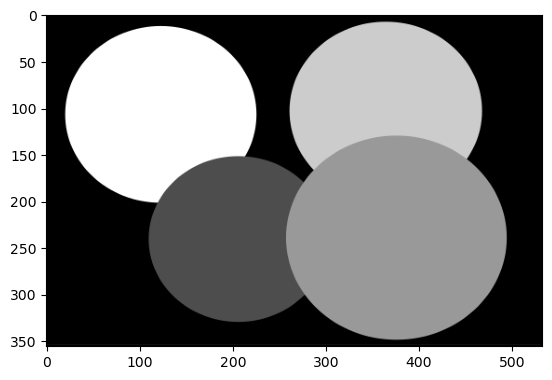

In [2]:
img=img_as_float(io.imread('./resources/circles.png'))
plt.imshow(img, cmap='gray')
plt.show()

#### 11.1.2

Perform a segmentation of the image using thresholding. Find a suitable threshold value to segment the four shapes from the background. Display the resulting segmentation mask.

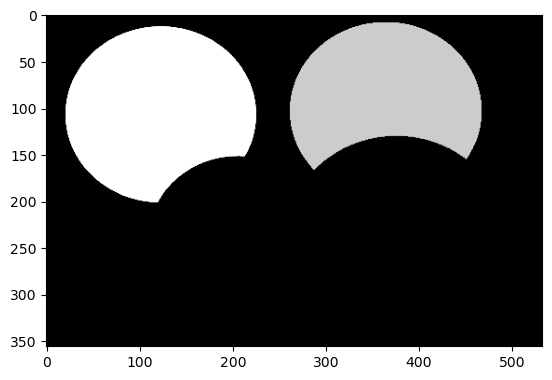

In [3]:
img_thresholded=(img>0.6)*img
plt.imshow(img_thresholded, cmap='gray');


#### 11.1.3

The necessity to manually select the threshold values for segmentation can be avoided by different threshold selection algorithms such as Otsu's algorithm. Using the `filters.threshold_otsu` function ([docs](https://scikit-image.org/docs/stable/api/skimage.filters.html#skimage.filters.threshold_otsu)), derive a suitable threshold for the given image. Segment the image using this threshold and display the resulting segmentation mask.

0.419921875


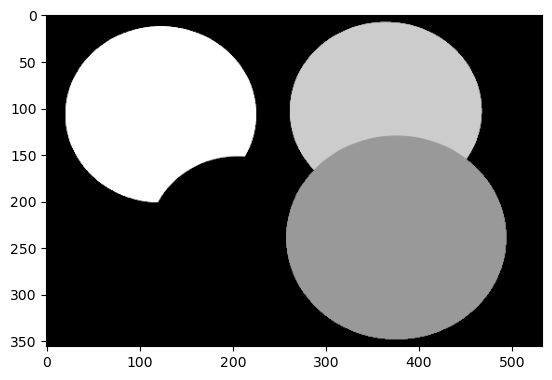

In [4]:
threshold=filters.threshold_otsu(img)
print(threshold)
thresholded_image=(img>threshold)*img
plt.imshow(thresholded_image, cmap='gray');

#### 11.1.4

Otsu's algorithm is also extendable to scenarios with multiple classes. Using the `filters.threshold_multiotsu` function ([docs](https://scikit-image.org/docs/stable/api/skimage.filters.html#skimage.filters.threshold_multiotsu)), derive suitable thresholds for the segmentation of the image. What is a reasonable number of classes to use for the given image? Display the segmentation mask for each class.

*Hint: The `np.digitize` function ([docs](https://numpy.org/doc/stable/reference/generated/numpy.digitize.html)) might be useful.*

[0.15039062 0.44726562 0.69726562 0.89648438]


array([0, 1, 2, 3, 4], dtype=int64)

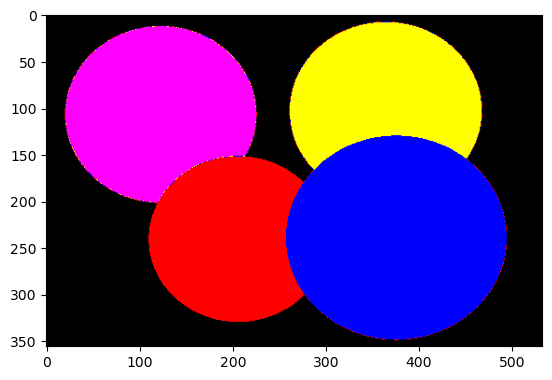

In [8]:
thresholds=filters.threshold_multiotsu(img, classes=5)
print(thresholds)
bins=np.digitize(img,thresholds)
thresholded_image=color.label2rgb(bins)
plt.imshow(thresholded_image);
np.unique(bins)